# 02 — Physics Aware Planner corrigé

Objectif :
- construire un planner court horizon basé sur la physique réelle de l'environnement ;
- tester des séquences d'actions en simulation ;
- visualiser les trajectoires ;
- disposer d'une base propre pour les notebooks suivants.

Corrections intégrées :
- imports compatibles avec l'architecture réelle du dépôt ;
- création correcte de l'environnement : `SailingEnv(**get_wind_scenario(name))` ;
- utilisation correcte de `env.world_map` ;
- suppression de `env.clone()`, qui n'existe pas ;
- utilisation de `copy.deepcopy(env)` pour les rollouts dans le notebook ;
- cellules conçues pour éviter les erreurs en cascade.


## 1. Imports et détection robuste du dépôt

In [1]:

from pathlib import Path
import os
import sys
import copy
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Si la détection automatique échoue, renseigne ici le chemin absolu du dépôt.
# Exemple Windows :
# MANUAL_REPO_ROOT = r"C:\\Users\\...\\stable_v2_RL_sailing_challenge"
MANUAL_REPO_ROOT = None


def safe_cwd():
    try:
        return Path.cwd().resolve()
    except FileNotFoundError:
        return Path.home().resolve()


def find_repo_root(manual_root=None):
    candidates = []

    if manual_root:
        candidates.append(Path(manual_root).expanduser().resolve())

    cwd = safe_cwd()
    candidates.extend([cwd] + list(cwd.parents))

    candidates.extend([
        Path("/mnt/data/stable_v2_RL_sailing_challenge"),
        Path("/mnt/data/sailing_repo/stable_v2_RL_sailing_challenge"),
        Path("/mnt/data/sailing/stable_v2_RL_sailing_challenge"),
        Path.home() / "stable_v2_RL_sailing_challenge",
    ])

    seen = set()
    for p in candidates:
        if p in seen:
            continue
        seen.add(p)

        if (p / "src" / "env_sailing.py").exists():
            return p

    raise FileNotFoundError(
        "Impossible de trouver le dépôt. "
        "Place ce notebook dans le dépôt ou renseigne MANUAL_REPO_ROOT."
    )


REPO_ROOT = find_repo_root(MANUAL_REPO_ROOT)
SRC_DIR = REPO_ROOT / "src"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT =", REPO_ROOT)
print("SRC_DIR   =", SRC_DIR)


REPO_ROOT = /home/onyxia/work/stable_v2_RL_sailing_challenge
SRC_DIR   = /home/onyxia/work/stable_v2_RL_sailing_challenge/src


In [2]:

from src.env_sailing import SailingEnv
from src.wind_scenarios import get_wind_scenario, WIND_SCENARIOS
from src.sailing_physics import calculate_sailing_efficiency

print("Imports OK.")
print("Scénarios disponibles :", list(WIND_SCENARIOS.keys()))


Imports OK.
Scénarios disponibles : ['training_1', 'training_2', 'training_3']


## 2. Créer l'environnement correctement

Dans ce dépôt, `get_wind_scenario(name)` renvoie un dictionnaire contenant les paramètres du scénario.  
Il faut donc créer l'environnement avec :

```python
env = SailingEnv(**get_wind_scenario(name))
```


In [3]:

SCENARIO_NAME = "training_1"

def make_env(scenario_name=SCENARIO_NAME, seed=0, static_wind=True, render_mode="rgb_array", show_full_trajectory=True):
    env = SailingEnv(
        **get_wind_scenario(scenario_name),
        static_wind=static_wind,
        render_mode=render_mode,
        show_full_trajectory=show_full_trajectory,
    )
    obs, info = env.reset(seed=seed)
    return env, obs, info


env, obs, info = make_env(SCENARIO_NAME, seed=0)

print("Scenario:", SCENARIO_NAME)
print("Observation shape:", obs.shape)
print("Position:", env.position)
print("Velocity:", env.velocity)
print("Goal:", env.goal_position)
print("World map shape:", env.world_map.shape)
print("Wind field shape:", env.wind_field.shape)
print("Info keys:", info.keys())


Scenario: training_1
Observation shape: (49158,)
Position: [64  0]
Velocity: [0. 0.]
Goal: [ 64 127]
World map shape: (128, 128)
Wind field shape: (128, 128, 2)
Info keys: dict_keys(['position', 'velocity', 'wind', 'step'])


## 3. Parser l'observation

In [4]:

def parse_observation(observation, grid_size=(128, 128)):
    W, H = grid_size
    observation = np.asarray(observation, dtype=np.float32)

    n_wind = W * H * 2
    n_world = W * H
    expected_len = 6 + n_wind + n_world

    if observation.shape[0] != expected_len:
        raise ValueError(
            f"Unexpected observation length: {observation.shape[0]} != {expected_len}"
        )

    position = observation[0:2].astype(np.float32)
    velocity = observation[2:4].astype(np.float32)
    local_wind = observation[4:6].astype(np.float32)

    wind_field = observation[6:6+n_wind].reshape(H, W, 2)
    world_map = observation[6+n_wind:6+n_wind+n_world].reshape(H, W)

    return {
        "position": position,
        "velocity": velocity,
        "local_wind": local_wind,
        "wind_field": wind_field,
        "world_map": world_map,
        "x": float(position[0]),
        "y": float(position[1]),
        "vx": float(velocity[0]),
        "vy": float(velocity[1]),
        "wx": float(local_wind[0]),
        "wy": float(local_wind[1]),
    }


state = parse_observation(obs, env.grid_size)

print("Parsed position:", state["position"])
print("Parsed velocity:", state["velocity"])
print("Parsed local wind:", state["local_wind"])
print("Maps match env.world_map:", np.allclose(state["world_map"], env.world_map))
print("Wind matches env.wind_field:", np.allclose(state["wind_field"], env.wind_field))


Parsed position: [64.  0.]
Parsed velocity: [0. 0.]
Parsed local wind: [-5.4554114  8.38084  ]
Maps match env.world_map: True
Wind matches env.wind_field: True


## 4. Actions disponibles

In [5]:

ACTION_NAMES = {
    0: "North",
    1: "North-East",
    2: "East",
    3: "South-East",
    4: "South",
    5: "South-West",
    6: "West",
    7: "North-West",
    8: "Stay",
}

rows = []
for action in range(9):
    d = env._action_to_direction(action)
    rows.append({
        "action": action,
        "name": ACTION_NAMES[action],
        "dx": int(d[0]),
        "dy": int(d[1]),
    })

actions_df = pd.DataFrame(rows)
display(actions_df)


,action,name,dx,dy
0,0,North,0,1
1,1,North-East,1,1
2,2,East,1,0
3,3,South-East,1,-1
4,4,South,0,-1
5,5,South-West,-1,-1
6,6,West,-1,0
7,7,North-West,-1,1
8,8,Stay,0,0


## 5. Carte, île, départ et objectif

Island cells: 2955
Island x-range: 38 90
Island y-range: 17 85
Start: (np.int64(64), np.int64(0))
Goal: (np.int64(64), np.int64(127))


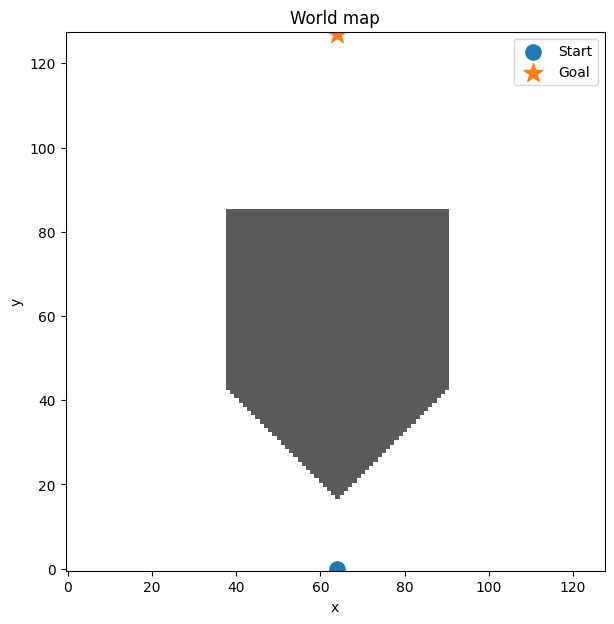

In [6]:

world_map = env.world_map

ys, xs = np.where(world_map == 1)

print("Island cells:", len(xs))
print("Island x-range:", int(xs.min()), int(xs.max()))
print("Island y-range:", int(ys.min()), int(ys.max()))
print("Start:", tuple(env.position))
print("Goal:", tuple(env.goal_position))

plt.figure(figsize=(7, 7))
plt.imshow(world_map, origin="lower", cmap="Greys", alpha=0.65)
plt.scatter([64], [0], s=120, marker="o", label="Start")
plt.scatter([64], [127], s=200, marker="*", label="Goal")
plt.title("World map")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


## 6. Fonctions de collision et de distance

In [7]:

def is_collision_xy(x, y, world):
    x = int(np.clip(round(float(x)), 0, world.shape[1] - 1))
    y = int(np.clip(round(float(y)), 0, world.shape[0] - 1))
    return bool(world[y, x] == 1)


def distance_to_goal(position, goal=np.array([64, 127])):
    position = np.asarray(position, dtype=float)
    goal = np.asarray(goal, dtype=float)
    return float(np.linalg.norm(position - goal))


def distance_to_island(position, world):
    position = np.asarray(position, dtype=float)

    ys, xs = np.where(world == 1)
    if len(xs) == 0:
        return np.inf

    d2 = (xs - position[0])**2 + (ys - position[1])**2
    return float(np.sqrt(d2.min()))


print("Collision center island:", is_collision_xy(64, 60, world_map))
print("Collision start:", is_collision_xy(64, 0, world_map))
print("Distance start-goal:", distance_to_goal(np.array([64, 0])))
print("Distance start-island:", distance_to_island(np.array([64, 0]), world_map))


Collision center island: True
Collision start: False
Distance start-goal: 127.0
Distance start-island: 17.0


## 7. Score heuristique d'une position

Le score interne n'est pas le reward officiel.  
Il sert seulement au planner pour choisir les actions candidates.

On veut :
- avancer vers le nord ;
- se rapprocher du goal ;
- garder une vitesse nord positive ;
- éviter l'île ;
- éviter les bords.


In [8]:

GOAL = np.array([64.0, 127.0], dtype=np.float32)


def heuristic_score(position, velocity, world):
    position = np.asarray(position, dtype=float)
    velocity = np.asarray(velocity, dtype=float)

    x, y = position
    vx, vy = velocity

    dist_goal = distance_to_goal(position, GOAL)
    dist_island = distance_to_island(position, world)

    score = 0.0

    # Progression générale vers le haut
    score += 4.0 * y

    # Proximité du goal
    score -= 0.6 * dist_goal

    # Vitesse vers le nord
    score += 5.0 * vy

    # Garder une marge à l'île
    if dist_island < 8:
        score -= 800.0 * (8 - dist_island)

    # Forte pénalité collision
    if is_collision_xy(x, y, world):
        score -= 1_000_000.0

    # Éviter les bords extrêmes
    if x < 4 or x > 123:
        score -= 2_000.0

    # Bonus terminal approximatif
    if dist_goal < 1.5:
        score += 1_000_000.0

    return float(score)


print("Score start:", heuristic_score(env.position, env.velocity, env.world_map))
print("Score near goal:", heuristic_score(np.array([64, 126]), np.array([0, 2]), env.world_map))
print("Score island center:", heuristic_score(np.array([64, 60]), np.array([0, 0]), env.world_map))


Score start: -76.2
Score near goal: 1000513.4
Score island center: -1006200.2


## 8. Rollout d'une séquence d'actions

Le dépôt ne contient pas `env.clone()`.  
Dans ce notebook d'analyse, on utilise donc :

```python
copy.deepcopy(env)
```

C'est acceptable pour explorer et diagnostiquer.  
Pour l'agent final Codabench, on évitera de dépendre d'un environnement interne.


In [9]:

def rollout_score(env, action_sequence):
    cloned = copy.deepcopy(env)

    total_score = 0.0
    reached_goal = False
    stuck = False

    for j, action in enumerate(action_sequence):
        obs, reward, terminated, truncated, info = cloned.step(int(action))

        total_score += heuristic_score(
            cloned.position,
            cloned.velocity,
            cloned.world_map,
        )

        # Reward officiel : si atteint, énorme bonus interne.
        if reward > 0:
            total_score += 1_000_000.0 / (1 + j)
            reached_goal = True

        if info.get("is_stuck", False):
            total_score -= 1_000_000.0
            stuck = True

        if terminated or truncated:
            break

    return float(total_score), reached_goal, stuck


# Test rapide
for seq in [[0, 0], [1, 1], [7, 7], [8, 8]]:
    score, reached, stuck = rollout_score(env, seq)
    print(seq, "score=", round(score, 2), "reached=", reached, "stuck=", stuck)


[0, 0] score= -95.2 reached= False stuck= False
[1, 1] score= -95.27 reached= False stuck= False
[7, 7] score= -128.61 reached= False stuck= False
[8, 8] score= -152.4 reached= False stuck= False


## 9. Choisir la meilleure action par planning court horizon

In [10]:

def candidate_sequences(horizon=2):
    actions = list(range(9))

    if horizon <= 1:
        return [[a] for a in actions]

    # Pour horizon=2, on peut tester toutes les paires.
    if horizon == 2:
        return [list(seq) for seq in product(actions, repeat=2)]

    # Pour horizon >= 3, on réduit un peu pour éviter d'exploser le temps.
    useful_actions = [0, 1, 2, 6, 7, 8]
    candidates = []

    # Actions répétées
    for a in actions:
        candidates.append([a] * horizon)

    # Une action de départ puis direction stable.
    for a in actions:
        for b in useful_actions:
            candidates.append([a] + [b] * (horizon - 1))

    # Petits motifs utiles pour tacking.
    motifs = [
        [1, 7],
        [7, 1],
        [0, 1],
        [0, 7],
        [1, 0],
        [7, 0],
    ]
    for motif in motifs:
        seq = (motif * ((horizon + len(motif) - 1) // len(motif)))[:horizon]
        candidates.append(seq)

    # Dédupliquer
    unique = []
    seen = set()
    for seq in candidates:
        key = tuple(seq)
        if key not in seen:
            seen.add(key)
            unique.append(seq)

    return unique


def choose_action(env, horizon=2, return_debug=False):
    best_score = -np.inf
    best_action = 0
    best_seq = None

    rows = []

    for seq in candidate_sequences(horizon=horizon):
        score, reached, stuck = rollout_score(env, seq)

        rows.append({
            "seq": tuple(seq),
            "first_action": seq[0],
            "score": score,
            "reached": reached,
            "stuck": stuck,
        })

        if score > best_score:
            best_score = score
            best_action = int(seq[0])
            best_seq = tuple(seq)

    debug = pd.DataFrame(rows).sort_values("score", ascending=False)

    if return_debug:
        return best_action, best_seq, best_score, debug

    return best_action


action, seq, score, debug = choose_action(env, horizon=2, return_debug=True)
print("Best action:", action, ACTION_NAMES[action])
print("Best sequence:", seq)
print("Best score:", score)
display(debug.head(10))


Best action: 0 North
Best sequence: (0, 0)
Best score: -95.2


,seq,first_action,score,reached,stuck
0,"(0, 0)",0,-95.200000,False,False
1,"(0, 1)",0,-95.209835,False,False
9,"(1, 0)",1,-95.219435,False,False
10,"(1, 1)",1,-95.271049,False,False
7,"(0, 7)",0,-104.802439,False,False
16,"(1, 7)",1,-104.812038,False,False
64,"(7, 1)",7,-109.404820,False,False
63,"(7, 0)",7,-119.004800,False,False
8,"(0, 8)",0,-124.000000,False,False
4,"(0, 4)",0,-124.000000,False,False


## 10. Tester le planner sur un épisode

In [11]:

def run_planner_episode(scenario_name="training_1", seed=0, horizon=2, max_steps=500, static_wind=True):
    env, obs, info = make_env(
        scenario_name=scenario_name,
        seed=seed,
        static_wind=static_wind,
        render_mode="rgb_array",
        show_full_trajectory=True,
    )

    trajectory = [env.position.copy()]
    actions = []
    rewards = []
    infos = []

    terminated = False
    truncated = False

    for step in range(max_steps):
        action = choose_action(env, horizon=horizon)

        obs, reward, terminated, truncated, info = env.step(action)

        trajectory.append(env.position.copy())
        actions.append(action)
        rewards.append(float(reward))
        infos.append(info)

        if terminated or truncated:
            break

    result = {
        "scenario": scenario_name,
        "seed": seed,
        "horizon": horizon,
        "steps": len(actions),
        "reward_sum": float(np.sum(rewards)),
        "success": bool(np.sum(rewards) > 0),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "is_stuck": bool(infos[-1].get("is_stuck", False)) if infos else False,
        "final_position": trajectory[-1].tolist(),
    }

    return result, np.array(trajectory), actions, rewards, infos, env


result, trajectory, actions, rewards, infos, env_run = run_planner_episode(
    scenario_name="training_1",
    seed=0,
    horizon=2,
    max_steps=500,
    static_wind=True,
)

result


{'scenario': 'training_1',
 'seed': 0,
 'horizon': 2,
 'steps': 56,
 'reward_sum': 100.0,
 'success': True,
 'terminated': True,
 'truncated': False,
 'is_stuck': False,
 'final_position': [63, 127]}

## 11. Visualiser la trajectoire

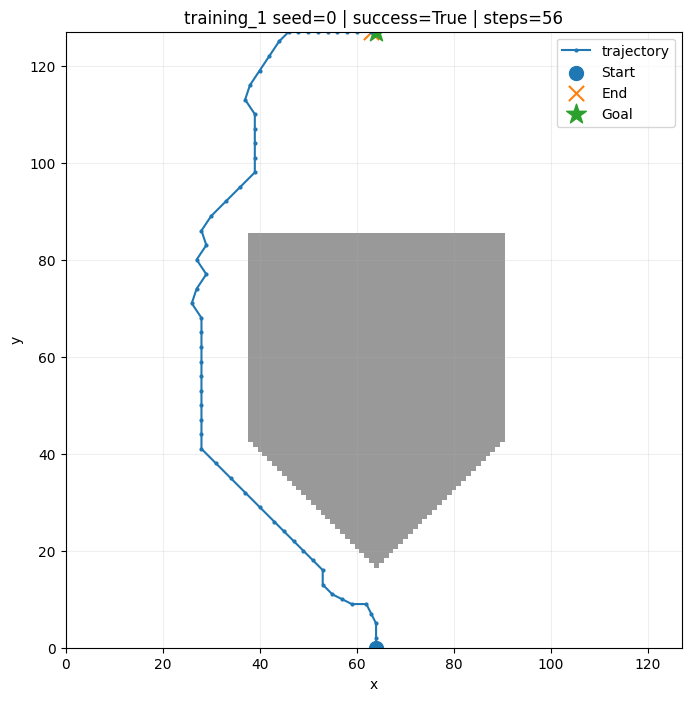

In [12]:

def plot_trajectory(trajectory, env, title=None):
    plt.figure(figsize=(8, 8))
    plt.imshow(env.world_map, origin="lower", cmap="Greys", alpha=0.4)

    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        marker="o",
        markersize=2,
        linewidth=1.5,
        label="trajectory",
    )

    plt.scatter([trajectory[0, 0]], [trajectory[0, 1]], s=100, marker="o", label="Start")
    plt.scatter([trajectory[-1, 0]], [trajectory[-1, 1]], s=120, marker="x", label="End")
    plt.scatter([64], [127], s=220, marker="*", label="Goal")

    plt.title(title or "Planner trajectory")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(0, 127)
    plt.ylim(0, 127)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


plot_trajectory(
    trajectory,
    env_run,
    title=f"{result['scenario']} seed={result['seed']} | success={result['success']} | steps={result['steps']}",
)


## 12. Diagnostics actions / vitesse / distance

,step,x,y,next_x,next_y,action,action_name,reward,distance_to_goal,is_stuck
0,0,64.0,0.0,64.0,2.0,0,North,0.0,125.000000,False
1,1,64.0,2.0,64.0,5.0,0,North,0.0,122.000000,False
2,2,64.0,5.0,63.0,7.0,7,North-West,0.0,120.004167,False
3,3,63.0,7.0,62.0,9.0,7,North-West,0.0,118.016948,False
4,4,62.0,9.0,59.0,9.0,6,West,0.0,118.105885,False


,step,x,y,next_x,next_y,action,action_name,reward,distance_to_goal,is_stuck
51,51,52.0,127.0,54.0,127.0,1,North-East,0.0,10.0,False
52,52,54.0,127.0,56.0,127.0,1,North-East,0.0,8.0,False
53,53,56.0,127.0,58.0,127.0,1,North-East,0.0,6.0,False
54,54,58.0,127.0,60.0,127.0,1,North-East,0.0,4.0,False
55,55,60.0,127.0,63.0,127.0,2,East,100.0,1.0,False


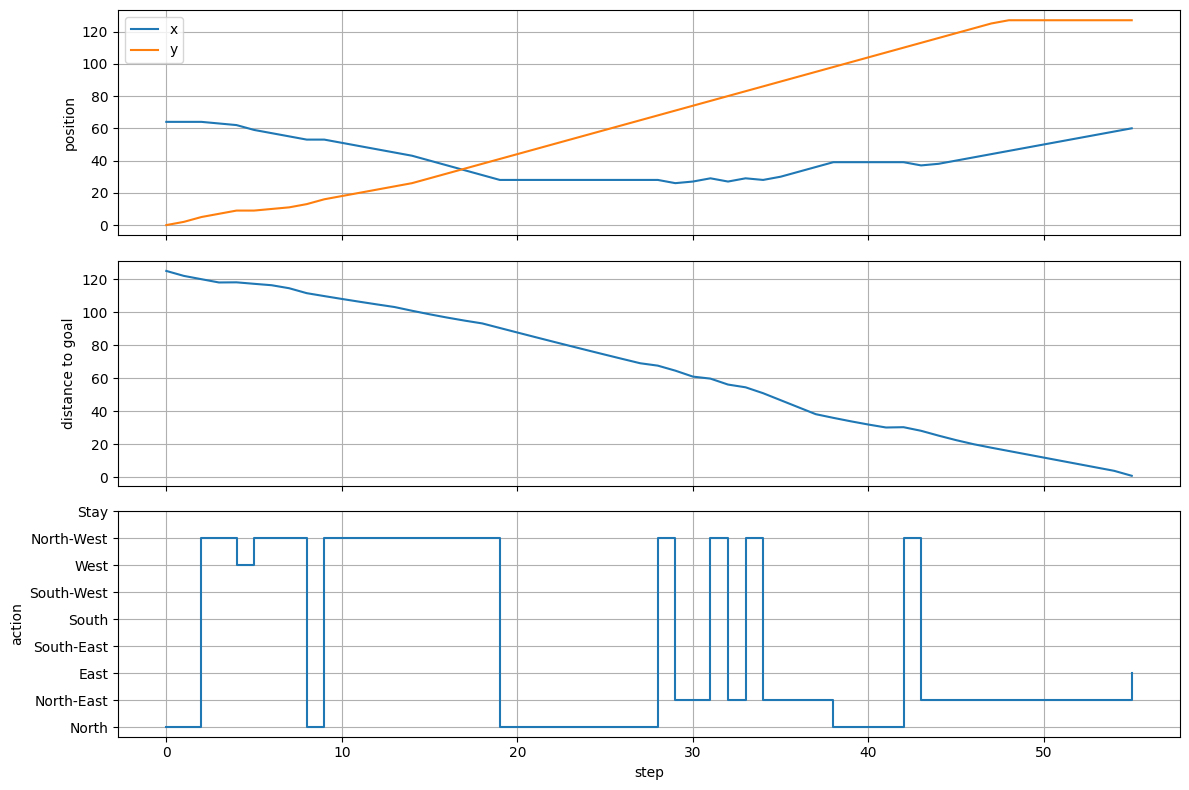

In [13]:

def build_episode_dataframe(trajectory, actions, rewards, infos):
    rows = []

    for t, action in enumerate(actions):
        pos = trajectory[t]
        next_pos = trajectory[t + 1]
        info = infos[t] if t < len(infos) else {}

        rows.append({
            "step": t,
            "x": float(pos[0]),
            "y": float(pos[1]),
            "next_x": float(next_pos[0]),
            "next_y": float(next_pos[1]),
            "action": int(action),
            "action_name": ACTION_NAMES[int(action)],
            "reward": float(rewards[t]),
            "distance_to_goal": float(info.get("distance_to_goal", np.nan)),
            "is_stuck": bool(info.get("is_stuck", False)),
        })

    return pd.DataFrame(rows)


episode_df = build_episode_dataframe(trajectory, actions, rewards, infos)
display(episode_df.head())
display(episode_df.tail())

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(episode_df["step"], episode_df["x"], label="x")
axes[0].plot(episode_df["step"], episode_df["y"], label="y")
axes[0].set_ylabel("position")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(episode_df["step"], episode_df["distance_to_goal"])
axes[1].set_ylabel("distance to goal")
axes[1].grid(True)

axes[2].step(episode_df["step"], episode_df["action"], where="post")
axes[2].set_ylabel("action")
axes[2].set_xlabel("step")
axes[2].set_yticks(list(ACTION_NAMES.keys()))
axes[2].set_yticklabels([ACTION_NAMES[k] for k in ACTION_NAMES])
axes[2].grid(True)

plt.tight_layout()
plt.show()


## 13. Test multi-seeds / multi-scénarios

Ce test est volontairement limité.  
Le planner avec `deepcopy` est coûteux, surtout si `horizon` augmente.


In [14]:

def evaluate_planner_small(scenarios=None, seeds=None, horizon=2, static_wind=True):
    if scenarios is None:
        scenarios = list(WIND_SCENARIOS.keys())

    if seeds is None:
        seeds = range(5)

    rows = []

    for scenario_name in scenarios:
        for seed in seeds:
            result, trajectory, actions, rewards, infos, env_run = run_planner_episode(
                scenario_name=scenario_name,
                seed=seed,
                horizon=horizon,
                max_steps=500,
                static_wind=static_wind,
            )
            rows.append(result)

            print(
                f"{scenario_name} seed={seed:02d} "
                f"success={result['success']} "
                f"steps={result['steps']} "
                f"stuck={result['is_stuck']}"
            )

    return pd.DataFrame(rows)


eval_df = evaluate_planner_small(
    scenarios=list(WIND_SCENARIOS.keys()),
    seeds=range(3),
    horizon=2,
    static_wind=True,
)

display(eval_df)

summary = (
    eval_df
    .groupby("scenario")
    .agg(
        success_rate=("success", "mean"),
        avg_steps=("steps", "mean"),
        stuck_rate=("is_stuck", "mean"),
    )
    .reset_index()
)

display(summary)


training_1 seed=00 success=True steps=56 stuck=False
training_1 seed=01 success=True steps=55 stuck=False
training_1 seed=02 success=True steps=95 stuck=False
training_2 seed=00 success=True steps=73 stuck=False
training_2 seed=01 success=True steps=69 stuck=False
training_2 seed=02 success=True steps=45 stuck=False
training_3 seed=00 success=True steps=100 stuck=False
training_3 seed=01 success=True steps=97 stuck=False
training_3 seed=02 success=True steps=249 stuck=False


,scenario,seed,horizon,steps,reward_sum,success,terminated,truncated,is_stuck,final_position
0,training_1,0,2,56,100.0,True,True,False,False,"[63, 127]"
1,training_1,1,2,55,100.0,True,True,False,False,"[63, 127]"
2,training_1,2,2,95,100.0,True,True,False,False,"[64, 127]"
3,training_2,0,2,73,100.0,True,True,False,False,"[63, 127]"
4,training_2,1,2,69,100.0,True,True,False,False,"[64, 127]"
5,training_2,2,2,45,100.0,True,True,False,False,"[65, 127]"
6,training_3,0,2,100,100.0,True,True,False,False,"[63, 127]"
7,training_3,1,2,97,100.0,True,True,False,False,"[63, 127]"
8,training_3,2,2,249,100.0,True,True,False,False,"[63, 127]"


,scenario,success_rate,avg_steps,stuck_rate
0,training_1,1.0,68.666667,0.0
1,training_2,1.0,62.333333,0.0
2,training_3,1.0,148.666667,0.0


## 14. Notes importantes pour la suite

Ce notebook sert à comprendre le planning physique avec l'environnement réel.

Pour Codabench :
- on ne doit pas embarquer l'environnement complet dans `my_agent.py` ;
- on ne doit pas utiliser `copy.deepcopy(env)` dans `act` ;
- on construira plutôt une simulation interne légère ou une heuristique fixe.

Le notebook suivant (`03_waypoint_strategy`) ajoutera une logique de waypoints pour contourner l'île plus efficacement.
